# Práctica 01: análisis $B^{\pm}\to J/\psi K^{\pm}$ con Uproot

In [1]:
from pathlib import Path
import sys
import numpy as np
from modulos import (
    build_cutflow,
    in_window,
    list_branches,
    load_arrays,
    print_cutflow,
)
from modulos.fitting import fit_and_plot, gaussian
from modulos.plotting import (
    plot_hist1d,
    plot_hist2d,
    plot_hist_comparison,
)

In [ ]:
module_candidates = (
    Path.cwd(),
    Path.cwd() / "Pruebas" / "Dec_Bpm",
)
for candidate in module_candidates:
    if (candidate / "modulos").is_dir():
        analysis_dir = candidate.resolve()
        break
else:
    raise FileNotFoundError(
        "No se encontró la carpeta modulos."
    )

if str(analysis_dir) not in sys.path:
    sys.path.insert(0, str(analysis_dir))

print("Intérprete de Python:", sys.executable)

columns = list_branches()
arrays = load_arrays(["Bplus_M", "J_psi_1S_M", "Bplus_PT", "Bplus_ID"])
b_mass = arrays["Bplus_M"]
jpsi_mass = arrays["J_psi_1S_M"]
b_pt = arrays["Bplus_PT"]
b_id = arrays["Bplus_ID"]

print(f"Candidatos cargados: {len(b_mass):,}")

Intérprete de Python: c:\Users\mario\AppData\Local\Programs\Python\Python312\python.exe
Candidatos cargados: 5,428,778


## Análisis exploratorio de columnas

In [ ]:
for column in columns:
    print(column)

BCID
BCType
Bplus_DIRA_OWNPV
Bplus_ENDVERTEX_CHI2
Bplus_ENDVERTEX_COV_
Bplus_ENDVERTEX_NDOF
Bplus_ENDVERTEX_X
Bplus_ENDVERTEX_XERR
Bplus_ENDVERTEX_Y
Bplus_ENDVERTEX_YERR
Bplus_ENDVERTEX_Z
Bplus_ENDVERTEX_ZERR
Bplus_FDCHI2_OWNPV
Bplus_FD_OWNPV
Bplus_ID
Bplus_IPCHI2_OWNPV
Bplus_IP_OWNPV
Bplus_M
Bplus_MM
Bplus_MMERR
Bplus_OWNPV_CHI2
Bplus_OWNPV_COV_
Bplus_OWNPV_NDOF
Bplus_OWNPV_X
Bplus_OWNPV_XERR
Bplus_OWNPV_Y
Bplus_OWNPV_YERR
Bplus_OWNPV_Z
Bplus_OWNPV_ZERR
Bplus_P
Bplus_PE
Bplus_PT
Bplus_PX
Bplus_PY
Bplus_PZ
EventInSequence
GpsTime
HLT1TCK
HLT2TCK
J_psi_1S_DIRA_ORIVX
J_psi_1S_DIRA_OWNPV
J_psi_1S_ENDVERTEX_CHI2
J_psi_1S_ENDVERTEX_COV_
J_psi_1S_ENDVERTEX_NDOF
J_psi_1S_ENDVERTEX_X
J_psi_1S_ENDVERTEX_XERR
J_psi_1S_ENDVERTEX_Y
J_psi_1S_ENDVERTEX_YERR
J_psi_1S_ENDVERTEX_Z
J_psi_1S_ENDVERTEX_ZERR
J_psi_1S_FDCHI2_ORIVX
J_psi_1S_FDCHI2_OWNPV
J_psi_1S_FD_ORIVX
J_psi_1S_FD_OWNPV
J_psi_1S_ID
J_psi_1S_IPCHI2_OWNPV
J_psi_1S_IP_OWNPV
J_psi_1S_M
J_psi_1S_MM
J_psi_1S_MMERR
J_psi_1S_ORIVX_CHI2
J_psi_1S_OR

## Histograma de masa del candidato B

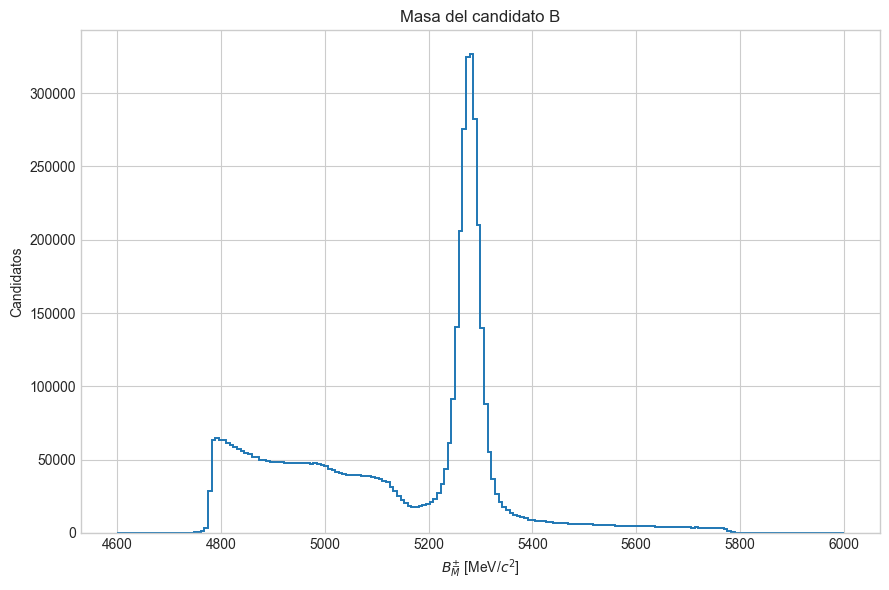

(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'center': 'Masa del candidato B'}, xlabel='$B^{\\pm}_M$ [MeV/$c^2$]', ylabel='Candidatos'>,
 WindowsPath('C:/Users/mario/Documents/PF/Pruebas/Dec_Bpm/UpROOT/figs/p01_bmass01_uproot.png'))

In [3]:
plot_hist1d(
    b_mass,
    bins=200,
    value_range=(4600, 6000),
    title="Masa del candidato B",
    xlabel=r"$B^{\pm}_M$ [MeV/$c^2$]",
    filename="p01_bmass01_uproot.png",
)


## Corte en la masa del $J/\psi$

`in_window` devuelve una máscara booleana de NumPy equivalente a `RDataFrame.Filter`.

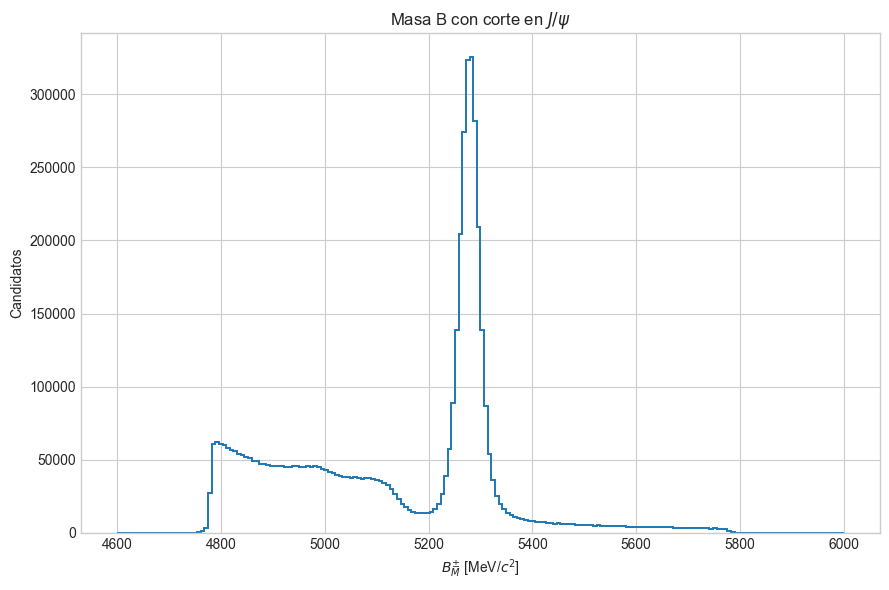

(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'center': 'Masa B con corte en $J/\\psi$'}, xlabel='$B^{\\pm}_M$ [MeV/$c^2$]', ylabel='Candidatos'>,
 WindowsPath('C:/Users/mario/Documents/PF/Pruebas/Dec_Bpm/UpROOT/figs/p01_bmass_jpsi_cut01_uproot.png'))

In [4]:
mask_jpsi = in_window(jpsi_mass, 3050, 3150)
b_mass_jpsi = b_mass[mask_jpsi]

plot_hist1d(
    b_mass_jpsi,
    bins=200,
    value_range=(4600, 6000),
    title=r"Masa B con corte en $J/\psi$",
    xlabel=r"$B^{\pm}_M$ [MeV/$c^2$]",
    filename="p01_bmass_jpsi_cut01_uproot.png",
)


## Comparación antes y después del corte

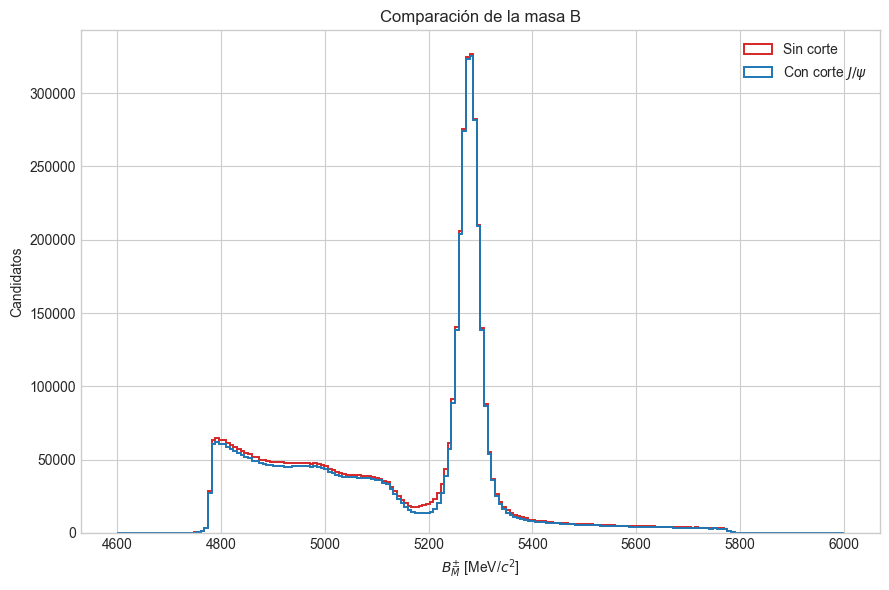

(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'center': 'Comparación de la masa B'}, xlabel='$B^{\\pm}_M$ [MeV/$c^2$]', ylabel='Candidatos'>,
 WindowsPath('C:/Users/mario/Documents/PF/Pruebas/Dec_Bpm/UpROOT/figs/p01_comparacion_cortes_uproot.png'))

In [5]:
plot_hist_comparison(
    {
        "Sin corte": b_mass,
        r"Con corte $J/\psi$": b_mass_jpsi,
    },
    bins=200,
    value_range=(4600, 6000),
    title="Comparación de la masa B",
    xlabel=r"$B^{\pm}_M$ [MeV/$c^2$]",
    filename="p01_comparacion_cortes_uproot.png",
)


## Eficiencia de cortes

In [6]:
mask_b = in_window(b_mass, 5000, 5600)
cutflow = build_cutflow(
    len(b_mass),
    {
        "Ventana J/psi": mask_jpsi,
        "Ventana J/psi + ventana B": mask_jpsi & mask_b,
    },
)
print_cutflow(cutflow)


Inicial                        :  5,428,778 (100.00 % del total)
Ventana J/psi                  :  5,191,777 ( 95.63 % del total)
Ventana J/psi + ventana B      :  3,513,952 ( 64.73 % del total)


## Ajuste gaussiano de la masa B

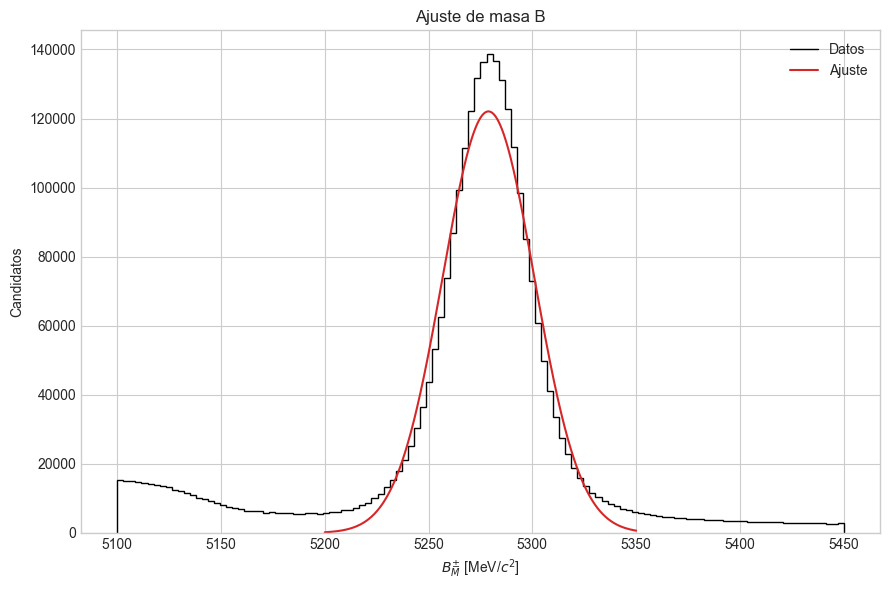

amplitud: 122058 ± 104
media: 5278.85 ± 0.0146
sigma: 22.0896 ± 0.0122
Media aproximada: 5278.853 MeV/c²
Sigma aproximada: 22.090 MeV/c²


In [7]:
fit_counts, _ = np.histogram(b_mass_jpsi, bins=120, range=(5100, 5450))
fit_result = fit_and_plot(
    b_mass_jpsi,
    model_name="gaussian",
    model=gaussian,
    initial_parameters=[max(fit_counts.max(), 1), 5280, 20],
    bounds=([0, 5200, 1], [np.inf, 5350, 100]),
    parameter_names=["amplitud", "media", "sigma"],
    bins=120,
    histogram_range=(5100, 5450),
    fit_range=(5200, 5350),
    title="Ajuste de masa B",
    xlabel=r"$B^{\pm}_M$ [MeV/$c^2$]",
    filename="p01_fit_bmass_uproot.png",
)

print(f"Media aproximada: {fit_result.parameters[1]:.3f} MeV/c²")
print(f"Sigma aproximada: {fit_result.parameters[2]:.3f} MeV/c²")


## Distribuciones cinemáticas

In [8]:
for column in columns:
    if "_PT" in column or "_P" in column or "_ETA" in column:
        print(column)


Bplus_P
Bplus_PE
Bplus_PT
Bplus_PX
Bplus_PY
Bplus_PZ
J_psi_1S_P
J_psi_1S_PE
J_psi_1S_PT
J_psi_1S_PX
J_psi_1S_PY
J_psi_1S_PZ
Kplus_MC12TuneV2_ProbNNe
Kplus_MC12TuneV2_ProbNNghost
Kplus_MC12TuneV2_ProbNNk
Kplus_MC12TuneV2_ProbNNmu
Kplus_MC12TuneV2_ProbNNp
Kplus_MC12TuneV2_ProbNNpi
Kplus_MC12TuneV3_ProbNNe
Kplus_MC12TuneV3_ProbNNghost
Kplus_MC12TuneV3_ProbNNk
Kplus_MC12TuneV3_ProbNNmu
Kplus_MC12TuneV3_ProbNNp
Kplus_MC12TuneV3_ProbNNpi
Kplus_MC12TuneV4_ProbNNe
Kplus_MC12TuneV4_ProbNNghost
Kplus_MC12TuneV4_ProbNNk
Kplus_MC12TuneV4_ProbNNmu
Kplus_MC12TuneV4_ProbNNp
Kplus_MC12TuneV4_ProbNNpi
Kplus_MC15TuneV1_ProbNNe
Kplus_MC15TuneV1_ProbNNghost
Kplus_MC15TuneV1_ProbNNk
Kplus_MC15TuneV1_ProbNNmu
Kplus_MC15TuneV1_ProbNNp
Kplus_MC15TuneV1_ProbNNpi
Kplus_P
Kplus_PE
Kplus_PIDK
Kplus_PIDd
Kplus_PIDe
Kplus_PIDmu
Kplus_PIDp
Kplus_PT
Kplus_PX
Kplus_PY
Kplus_PZ
Kplus_ProbNNd
Kplus_ProbNNe
Kplus_ProbNNghost
Kplus_ProbNNk
Kplus_ProbNNmu
Kplus_ProbNNp
Kplus_ProbNNpi
muminus_MC12TuneV2_ProbNNe
muminus_MC12

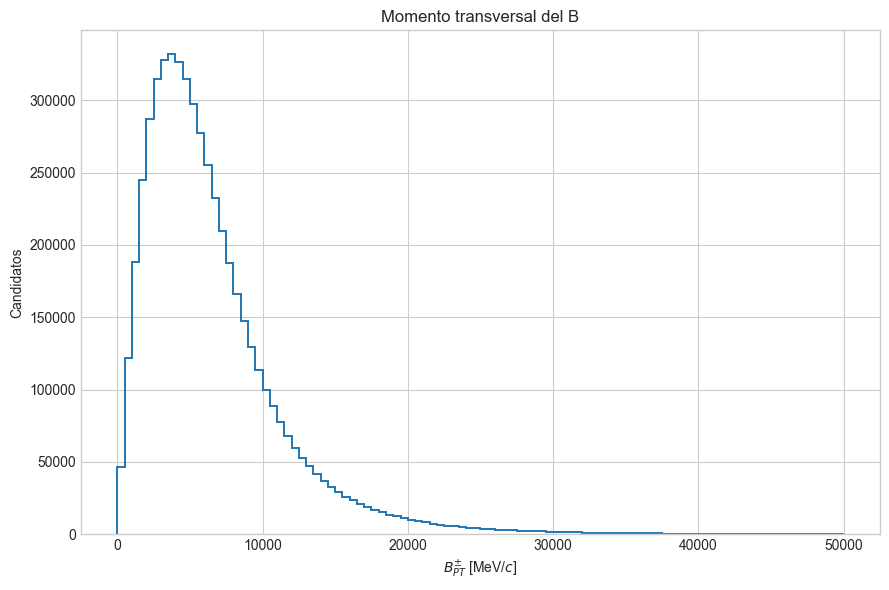

(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'center': 'Momento transversal del B'}, xlabel='$B^{\\pm}_{PT}$ [MeV/$c$]', ylabel='Candidatos'>,
 WindowsPath('C:/Users/mario/Documents/PF/Pruebas/Dec_Bpm/UpROOT/figs/p01_bplus_pt_uproot.png'))

In [9]:
plot_hist1d(
    b_pt,
    bins=100,
    value_range=(0, 50_000),
    title="Momento transversal del B",
    xlabel=r"$B^{\pm}_{PT}$ [MeV/$c$]",
    filename="p01_bplus_pt_uproot.png",
)


## Histogramas 2D: masa B frente a masa $J/\psi$

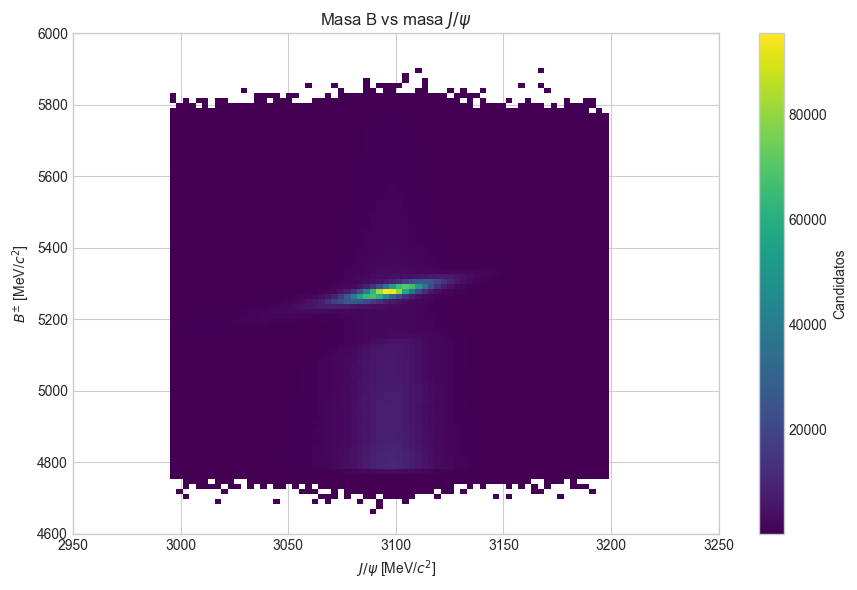

(<Figure size 900x600 with 2 Axes>,
 <Axes: title={'center': 'Masa B vs masa $J/\\psi$'}, xlabel='$J/\\psi$ [MeV/$c^2$]', ylabel='$B^{\\pm}$ [MeV/$c^2$]'>,
 WindowsPath('C:/Users/mario/Documents/PF/Pruebas/Dec_Bpm/UpROOT/figs/p01_bmasa_2d_uproot.png'))

In [10]:
plot_hist2d(
    jpsi_mass,
    b_mass,
    bins=(100, 100),
    value_range=((2950, 3250), (4600, 6000)),
    title=r"Masa B vs masa $J/\psi$",
    xlabel=r"$J/\psi$ [MeV/$c^2$]",
    ylabel=r"$B^{\pm}$ [MeV/$c^2$]",
    filename="p01_bmasa_2d_uproot.png",
)


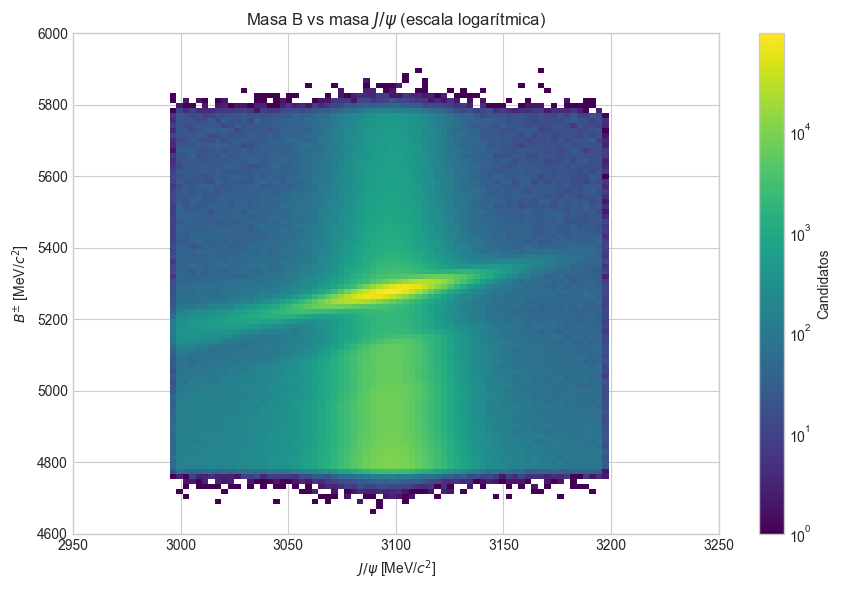

(<Figure size 900x600 with 2 Axes>,
 <Axes: title={'center': 'Masa B vs masa $J/\\psi$ (escala logarítmica)'}, xlabel='$J/\\psi$ [MeV/$c^2$]', ylabel='$B^{\\pm}$ [MeV/$c^2$]'>,
 WindowsPath('C:/Users/mario/Documents/PF/Pruebas/Dec_Bpm/UpROOT/figs/p01_bmasa_2d_log_uproot.png'))

In [11]:
plot_hist2d(
    jpsi_mass,
    b_mass,
    bins=(100, 100),
    value_range=((2950, 3250), (4600, 6000)),
    title=r"Masa B vs masa $J/\psi$ (escala logarítmica)",
    xlabel=r"$J/\psi$ [MeV/$c^2$]",
    ylabel=r"$B^{\pm}$ [MeV/$c^2$]",
    filename="p01_bmasa_2d_log_uproot.png",
    log_z=True,
)


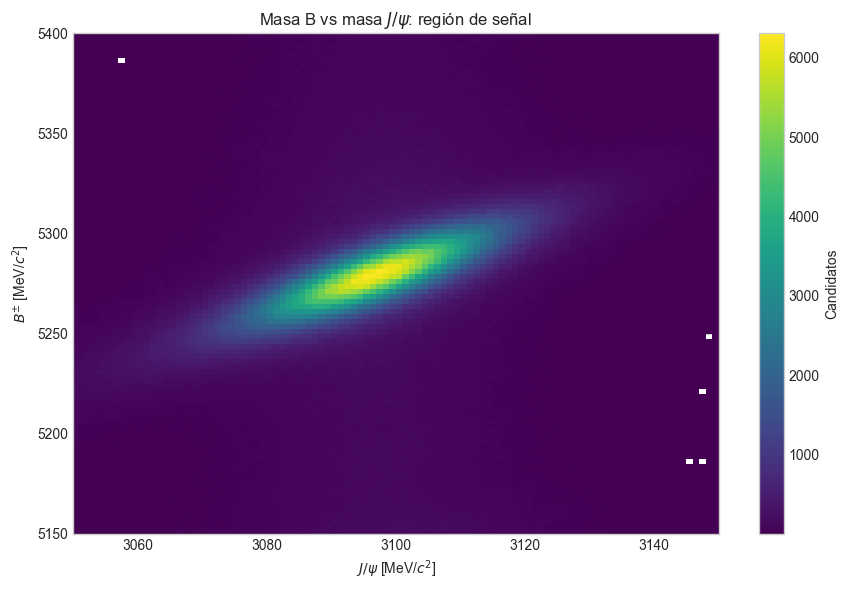

(<Figure size 900x600 with 2 Axes>,
 <Axes: title={'center': 'Masa B vs masa $J/\\psi$: región de señal'}, xlabel='$J/\\psi$ [MeV/$c^2$]', ylabel='$B^{\\pm}$ [MeV/$c^2$]'>,
 WindowsPath('C:/Users/mario/Documents/PF/Pruebas/Dec_Bpm/UpROOT/figs/p01_bmasa_2dz_uproot.png'))

In [12]:
plot_hist2d(
    jpsi_mass,
    b_mass,
    bins=(100, 100),
    value_range=((3050, 3150), (5150, 5400)),
    title=r"Masa B vs masa $J/\psi$: región de señal",
    xlabel=r"$J/\psi$ [MeV/$c^2$]",
    ylabel=r"$B^{\pm}$ [MeV/$c^2$]",
    filename="p01_bmasa_2dz_uproot.png",
)


## Separación de $B^+$ y $B^-$

In [13]:
for column in columns:
    if "ID" in column or "CHARGE" in column or "Q" in column:
        print(column)


BCID
Bplus_ID
J_psi_1S_ID
Kplus_ID
Kplus_PIDK
Kplus_PIDd
Kplus_PIDe
Kplus_PIDmu
Kplus_PIDp
muminus_ID
muminus_PIDK
muminus_PIDd
muminus_PIDe
muminus_PIDmu
muminus_PIDp
muplus_ID
muplus_PIDK
muplus_PIDd
muplus_PIDe
muplus_PIDmu
muplus_PIDp


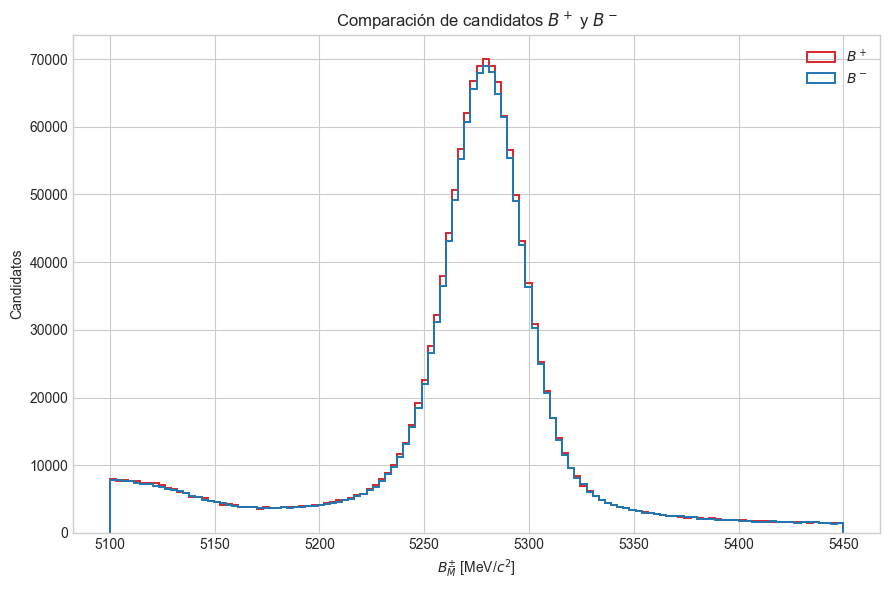

(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'center': 'Comparación de candidatos $B^+$ y $B^-$'}, xlabel='$B^{\\pm}_M$ [MeV/$c^2$]', ylabel='Candidatos'>,
 WindowsPath('C:/Users/mario/Documents/PF/Pruebas/Dec_Bpm/UpROOT/figs/p01_bplus_minus_uproot.png'))

In [14]:
plot_hist_comparison(
    {
        r"$B^+$": b_mass[b_id > 0],
        r"$B^-$": b_mass[b_id < 0],
    },
    bins=120,
    value_range=(5100, 5450),
    title=r"Comparación de candidatos $B^+$ y $B^-$",
    xlabel=r"$B^{\pm}_M$ [MeV/$c^2$]",
    filename="p01_bplus_minus_uproot.png",
)
